# British Airways - Task 2: EDA & Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 20)

In [2]:
df = pd.read_csv('customer_booking.csv', encoding='ISO-8859-1')

# Map flight_day to numeric (as in starter notebook)
day_map = {'Mon': 1, 'Tue': 2, 'Wed': 3, 'Thu': 4, 'Fri': 5, 'Sat': 6, 'Sun': 7}
df['flight_day'] = df['flight_day'].map(day_map)

print(df.shape)
df.head()

(50000, 14)


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,6,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,6,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,3,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,6,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,3,AKLDEL,India,1,0,1,5.52,0


---
## 1. Class Imbalance


Text(0, 0.5, 'Count')

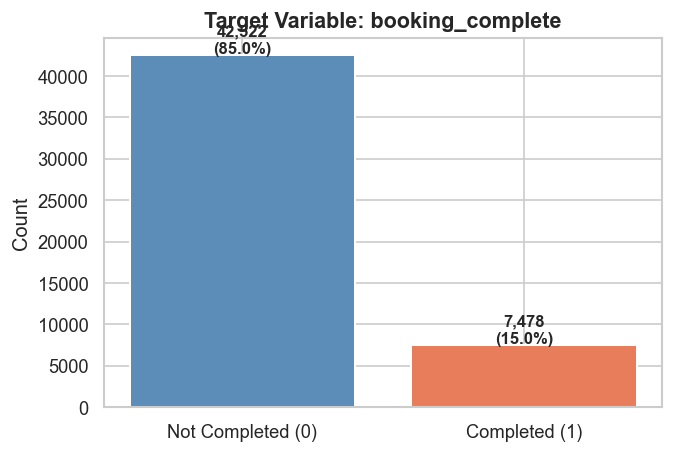

In [3]:
counts = df['booking_complete'].value_counts()
pct    = df['booking_complete'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(['Not Completed (0)', 'Completed (1)'], counts.values,
              color=['#5B8DB8', '#E87D5B'], edgecolor='white', linewidth=1.2)
for i, (c, p) in enumerate(zip(counts.values, pct.values)):
    ax.text(i, c + 200, f'{c:,}\n({p:.1f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Target Variable: booking_complete', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')

---
## 2. Numerical Feature Distributions


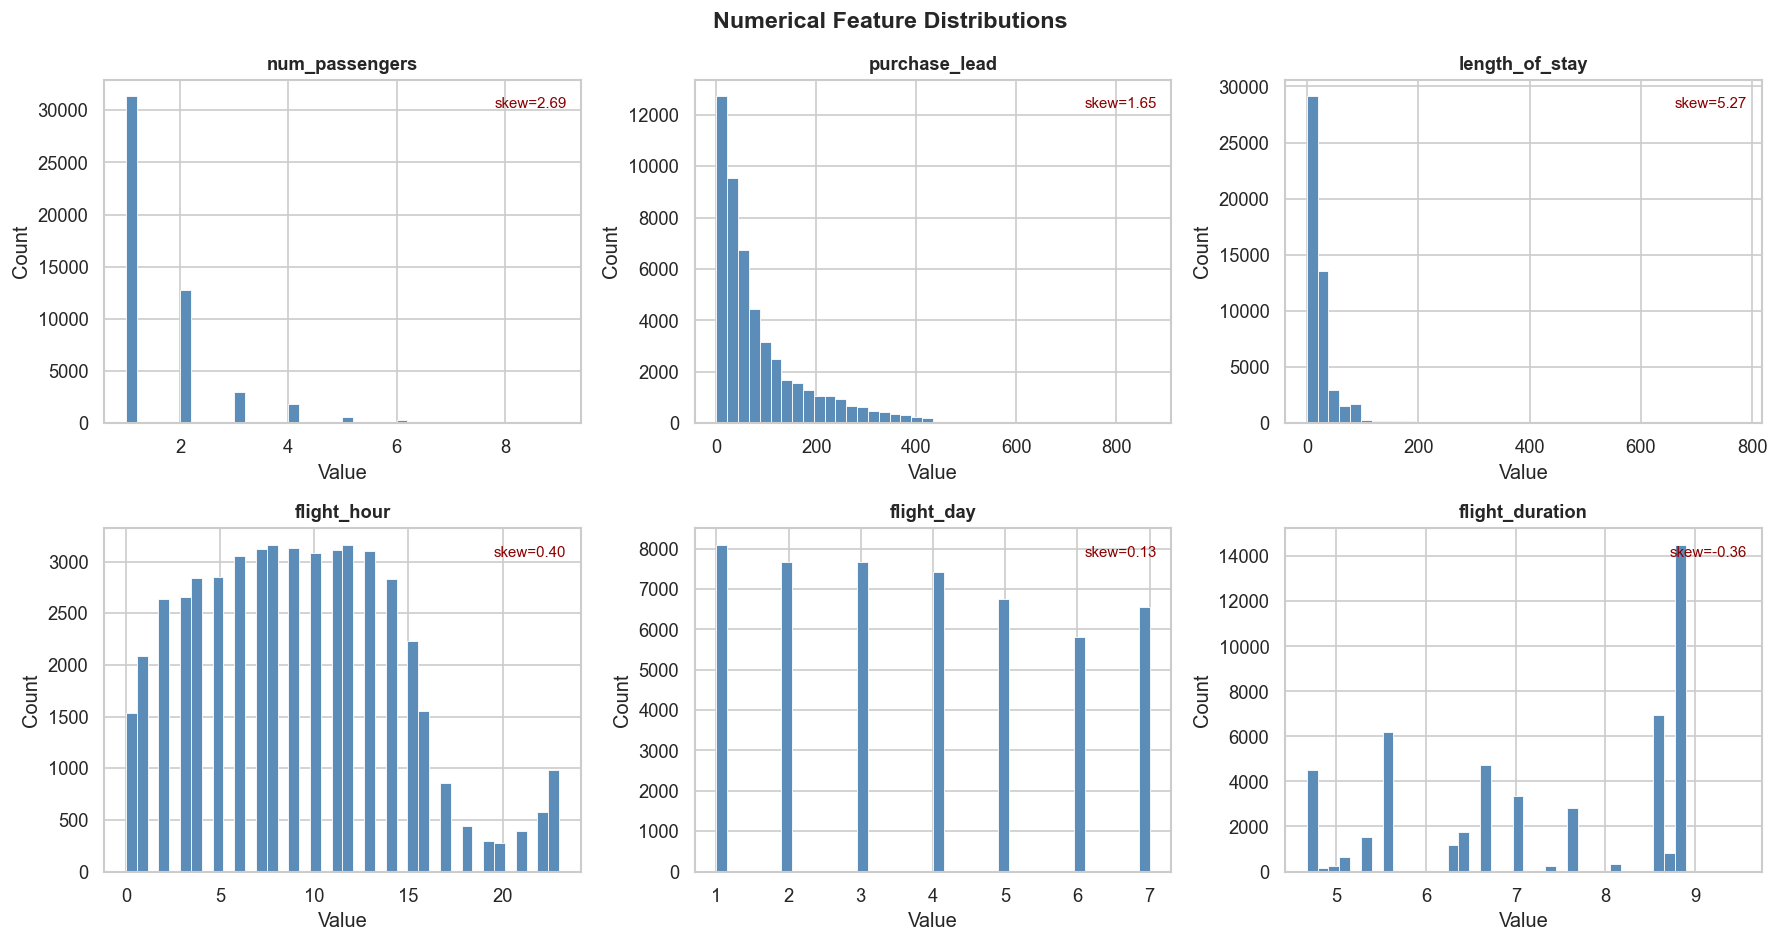

In [7]:
num_cols = ['num_passengers', 'purchase_lead', 'length_of_stay',
            'flight_hour', 'flight_day', 'flight_duration']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='#5B8DB8', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    skew = df[col].skew()
    axes[i].text(0.97, 0.95, f'skew={skew:.2f}', transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=9, color='darkred')

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Outlier Detection - Box Plots


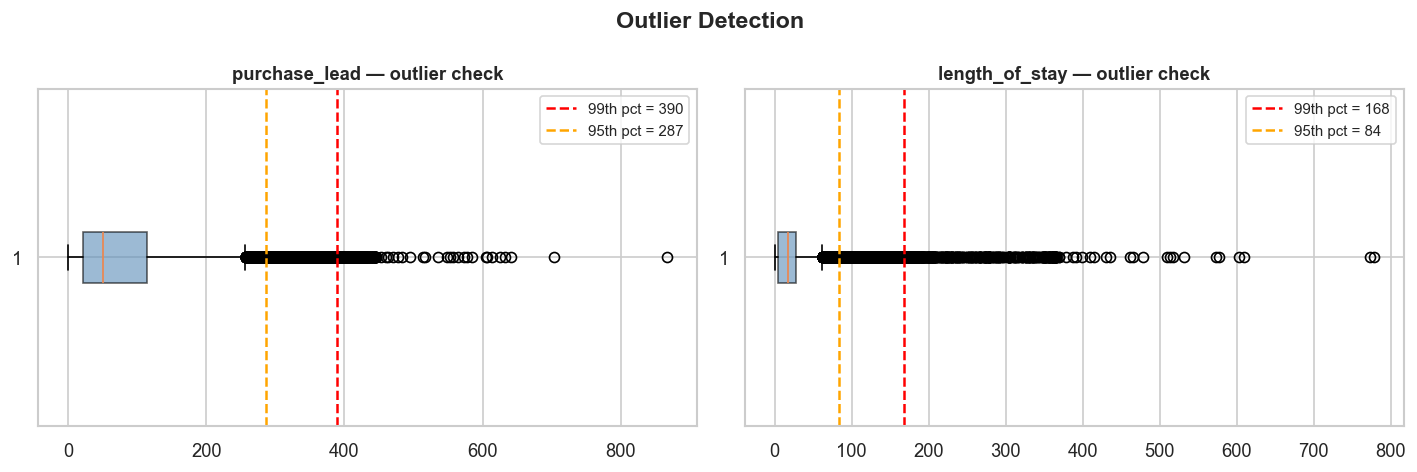

purchase_lead: max=867,  99th=390,  mean=84.9
length_of_stay: max=778,  99th=168,  mean=23.0


In [5]:
skewed_cols = ['purchase_lead', 'length_of_stay']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(skewed_cols):
    q99 = df[col].quantile(0.99)
    q95 = df[col].quantile(0.95)
    axes[i].boxplot(df[col], vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#5B8DB8', alpha=0.6))
    axes[i].axvline(q99, color='red',    linestyle='--', label=f'99th pct = {q99:.0f}')
    axes[i].axvline(q95, color='orange', linestyle='--', label=f'95th pct = {q95:.0f}')
    axes[i].set_title(f'{col} — outlier check', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for col in skewed_cols:
    print(f'{col}: max={df[col].max()},  99th={df[col].quantile(0.99):.0f},  mean={df[col].mean():.1f}')

---
## 4. Feature vs Target - Numerical (KDE Plots)

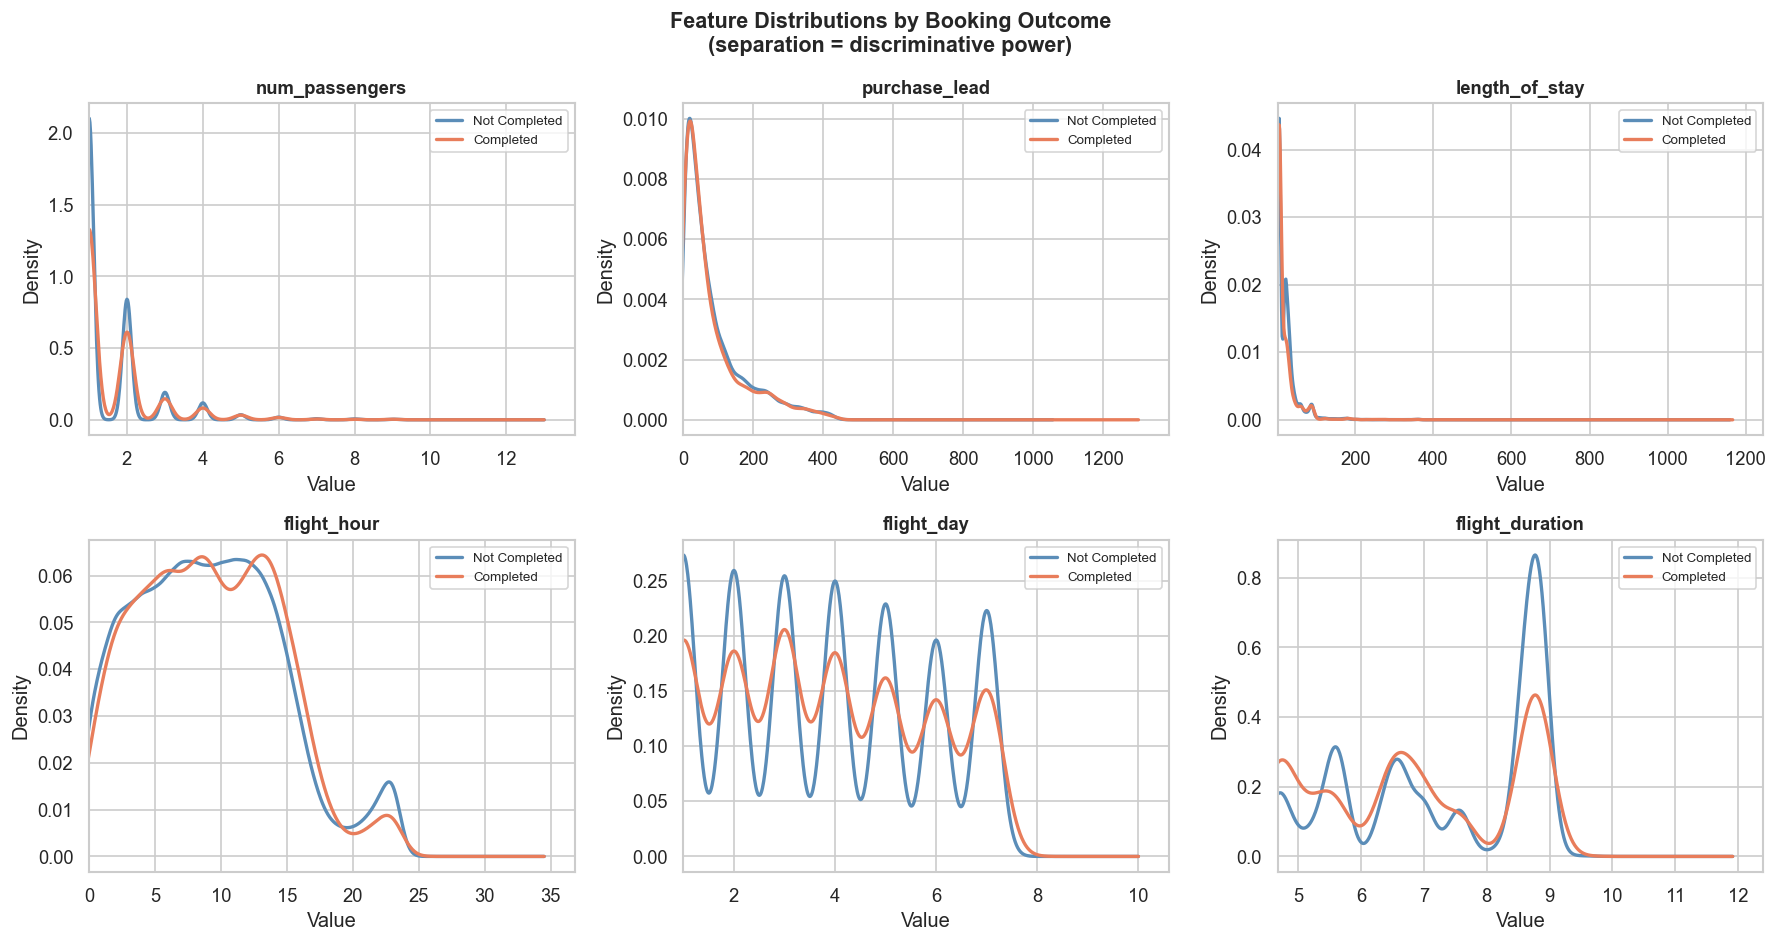

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = {0: '#5B8DB8', 1: '#E87D5B'}
labels = {0: 'Not Completed', 1: 'Completed'}

for i, col in enumerate(num_cols):
    for target_val in [0, 1]:
        subset = df[df['booking_complete'] == target_val][col]
        subset.plot.kde(ax=axes[i], label=labels[target_val],
                        color=colors[target_val], linewidth=2)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].legend(fontsize=8)
    axes[i].set_xlim(left=df[col].quantile(0.005))

plt.suptitle('Feature Distributions by Booking Outcome\n(separation = discriminative power)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Feature vs Target - Categorical (Completion Rate)

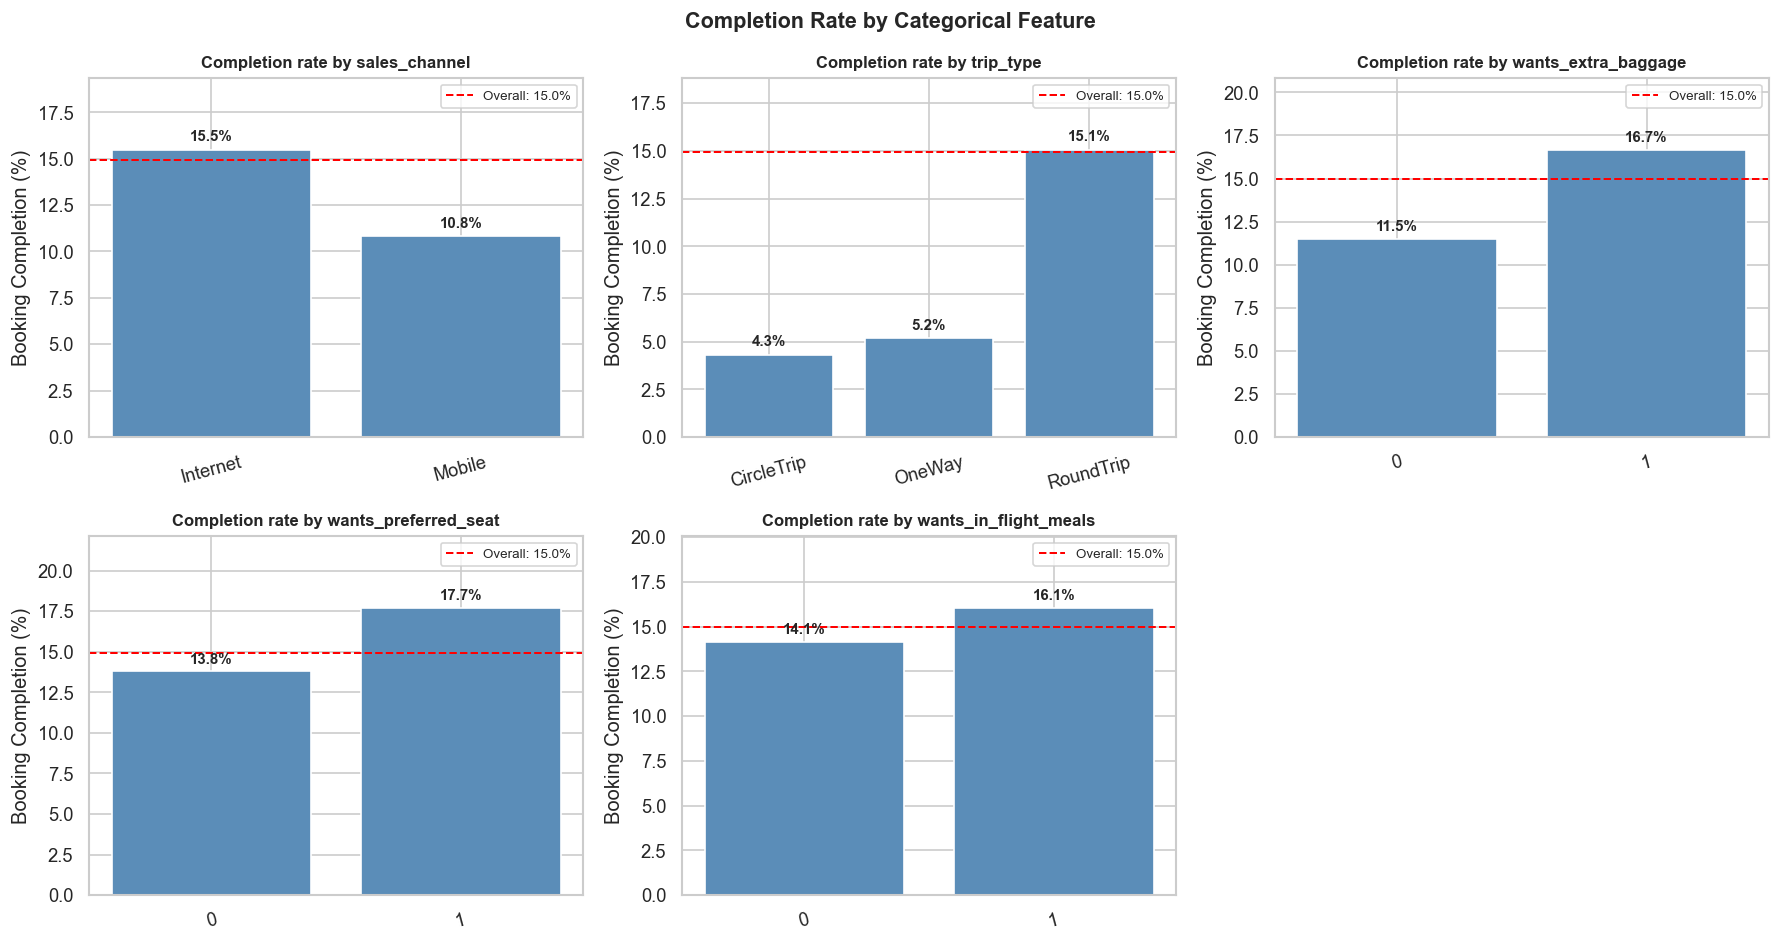

In [9]:
cat_cols = ['sales_channel', 'trip_type', 'wants_extra_baggage',
            'wants_preferred_seat', 'wants_in_flight_meals']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['booking_complete'].mean() * 100
    bars = axes[i].bar(rate.index.astype(str), rate.values,
                       color='#5B8DB8', edgecolor='white', linewidth=1)
    axes[i].axhline(df['booking_complete'].mean() * 100, color='red',
                    linestyle='--', linewidth=1.2, label=f'Overall: {df["booking_complete"].mean()*100:.1f}%')
    for bar, val in zip(bars, rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[i].set_title(f'Completion rate by {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Booking Completion (%)')
    axes[i].set_ylim(0, rate.max() * 1.25)
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=15)

axes[5].set_visible(False)
plt.suptitle('Completion Rate by Categorical Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Correlation Heatmap (Numeric Features)


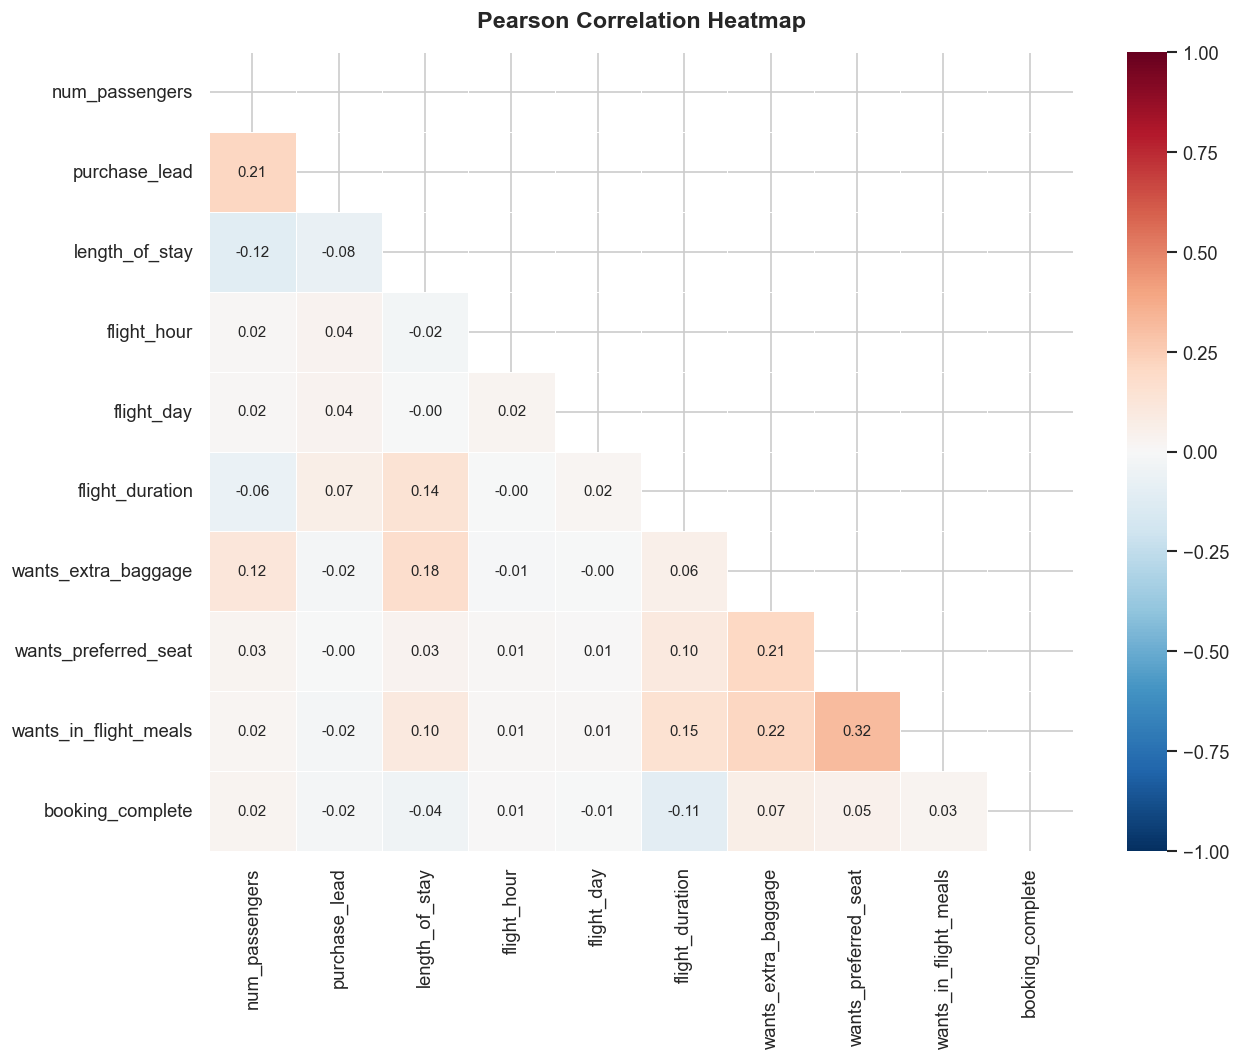


Correlation with booking_complete (sorted):
flight_duration         -0.106
wants_extra_baggage      0.068
wants_preferred_seat     0.050
length_of_stay          -0.042
wants_in_flight_meals    0.027
num_passengers           0.024
purchase_lead           -0.022
flight_hour              0.007
flight_day              -0.007
Name: booking_complete, dtype: float64


In [10]:
corr_cols = num_cols + ['wants_extra_baggage', 'wants_preferred_seat',
                         'wants_in_flight_meals', 'booking_complete']

corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Pearson Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\nCorrelation with booking_complete (sorted):')
print(corr['booking_complete'].drop('booking_complete').sort_values(key=abs, ascending=False).round(3))

---
## 7. Mutual Information Scores - Best Feature Selection Tool
Mutual Information (MI) measures how much each feature **reduces uncertainty** about the target - works for both numeric and categorical, and captures non-linear relationships unlike correlation.

- **MI = 0** → feature gives zero information about the target → can drop it
- **Higher MI** → more predictive power

Mutual Information Scores:
route                    0.0610
booking_origin           0.0455
flight_duration          0.0160
length_of_stay           0.0068
wants_extra_baggage      0.0024
purchase_lead            0.0017
wants_preferred_seat     0.0012
sales_channel            0.0009
flight_hour              0.0007
trip_type                0.0005
num_passengers           0.0004
wants_in_flight_meals    0.0003
flight_day               0.0002
dtype: float64


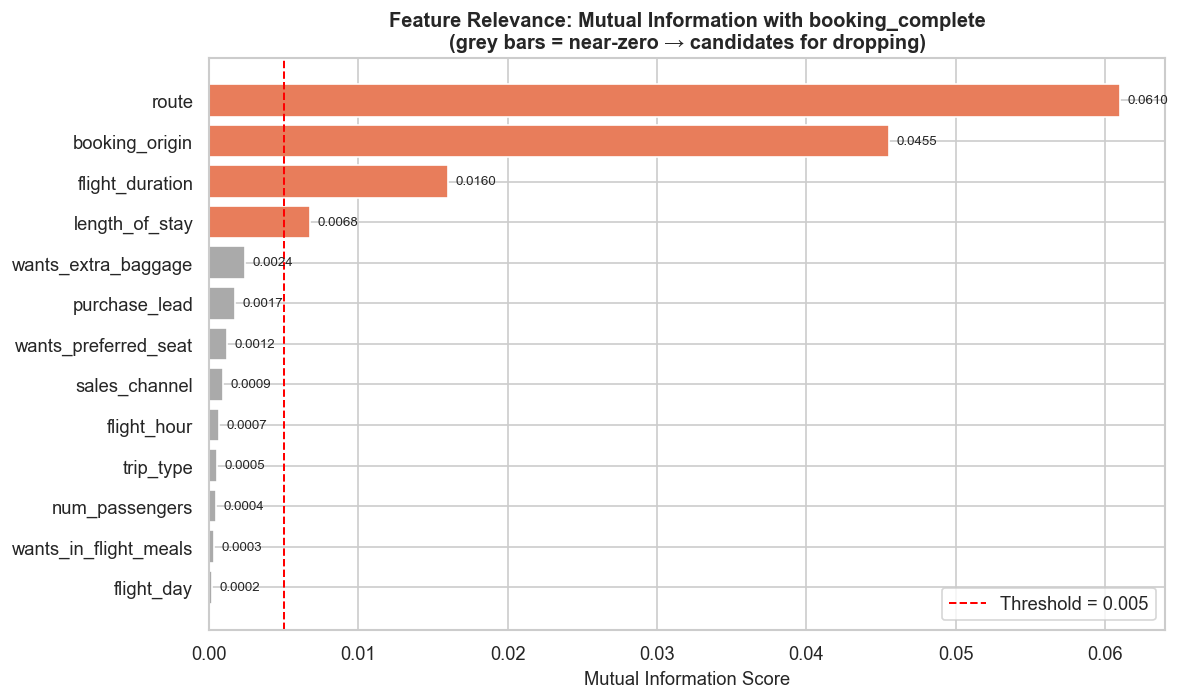

In [9]:
# Encode categoricals temporarily just for MI scoring
df_mi = df.copy()
for col in ['sales_channel', 'trip_type', 'route', 'booking_origin']:
    df_mi[col] = LabelEncoder().fit_transform(df_mi[col].astype(str))

feature_cols = [c for c in df_mi.columns if c != 'booking_complete']
X_mi = df_mi[feature_cols]
y_mi = df_mi['booking_complete']

# discrete_features: True for integer columns (treat as categorical)
discrete_mask = [X_mi[c].dtype == int or X_mi[c].nunique() < 20 for c in feature_cols]

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=discrete_mask, random_state=42)
mi_df = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print('Mutual Information Scores:')
print(mi_df.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
colors_mi = ['#E87D5B' if s > 0.005 else '#AAAAAA' for s in mi_df.values]
bars = ax.barh(mi_df.index[::-1], mi_df.values[::-1], color=colors_mi[::-1], edgecolor='white')
ax.axvline(0.005, color='red', linestyle='--', linewidth=1.2, label='Threshold = 0.005')
ax.set_xlabel('Mutual Information Score', fontsize=11)
ax.set_title('Feature Relevance: Mutual Information with booking_complete\n'
             '(grey bars = near-zero → candidates for dropping)', fontsize=12, fontweight='bold')
ax.legend()
for bar, val in zip(bars, mi_df.values[::-1]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## 8. Point-Biserial Correlation (Numeric Features vs Binary Target)

In [10]:
results = []
for col in num_cols:
    corr_val, pval = pointbiserialr(df[col], df['booking_complete'])
    results.append({'feature': col, 'correlation': round(corr_val, 4), 'p_value': round(pval, 6)})

pb_df = pd.DataFrame(results).sort_values('correlation', key=abs, ascending=False)
pb_df['significant'] = pb_df['p_value'] < 0.05
print(pb_df.to_string(index=False))

        feature  correlation  p_value  significant
flight_duration      -0.1063 0.000000         True
 length_of_stay      -0.0424 0.000000         True
 num_passengers       0.0241 0.000000         True
  purchase_lead      -0.0221 0.000001         True
    flight_hour       0.0071 0.111005        False
     flight_day      -0.0070 0.118288        False


---
## 9. Categorical Feature Cardinality



route: 799 unique values
route
AKLKUL    2680
PENTPE     924
MELSGN     842
ICNSIN     801
DMKKIX     744
ICNSYD     695
DMKPER     679
DPSICN     666
DMKOOL     655
MELPEN     649

booking_origin: 104 unique values
booking_origin
Australia      17872
Malaysia        7174
South Korea     4559
Japan           3885
China           3387
Indonesia       2369
Taiwan          2077
Thailand        2030
India           1270
New Zealand     1074


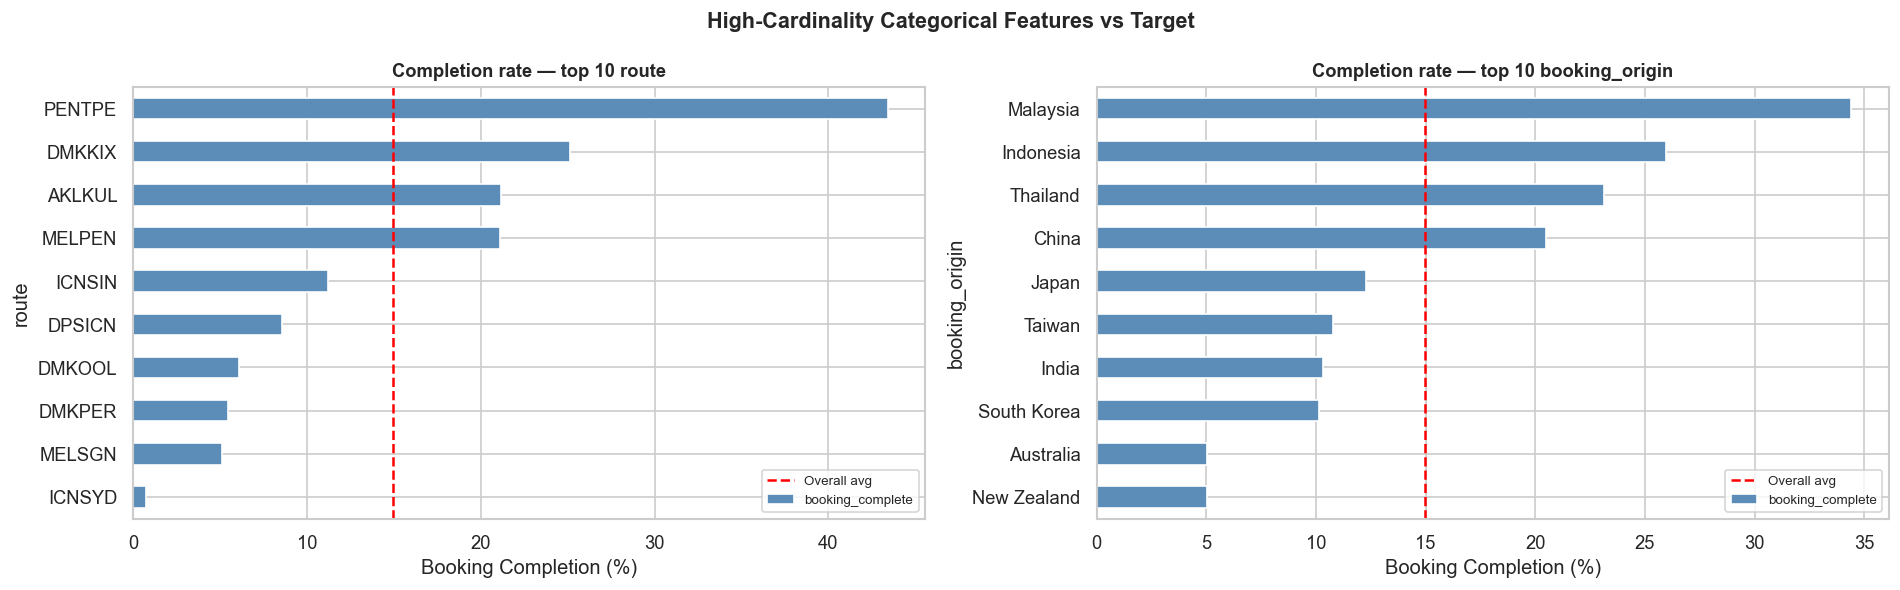

In [11]:
cat_high = ['route', 'booking_origin']

for col in cat_high:
    n = df[col].nunique()
    top10 = df[col].value_counts().head(10)
    print(f'\n{col}: {n} unique values')
    print(top10.to_string())

# Completion rate by top-10 booking origins
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, col in enumerate(cat_high):
    top_cats = df[col].value_counts().head(10).index
    rate = df[df[col].isin(top_cats)].groupby(col)['booking_complete'].mean().sort_values() * 100
    rate.plot.barh(ax=axes[i], color='#5B8DB8')
    axes[i].axvline(df['booking_complete'].mean() * 100, color='red',
                    linestyle='--', label='Overall avg')
    axes[i].set_title(f'Completion rate — top 10 {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Booking Completion (%)')
    axes[i].legend(fontsize=8)

plt.suptitle('High-Cardinality Categorical Features vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Data Transforms
**Steps**: split first, then fit all transforms on training data only, apply to test.

Steps:
1. Feature engineering (new columns)
2. Train/test split
3. Log transforms for skewed numerics
4. One-hot encode `sales_channel` and `trip_type`
5. Frequency encode `route` and `booking_origin` (fitted on train only)
6. Drop original columns that have been replaced

In [12]:
# --- Feature Engineering (no data leakage risk — pure column arithmetic) ---
df_prep = df.copy()

# Split route into origin and destination airport codes
df_prep['route_origin'] = df_prep['route'].str[:3]
df_prep['route_dest']   = df_prep['route'].str[3:]

# Total ancillaries requested (sum of 3 binary flags)
df_prep['total_ancillaries'] = (df_prep['wants_extra_baggage'] +
                                 df_prep['wants_preferred_seat'] +
                                 df_prep['wants_in_flight_meals'])

# Is weekend flight
df_prep['is_weekend'] = df_prep['flight_day'].isin([6, 7]).astype(int)

# Is solo traveller
df_prep['is_solo'] = (df_prep['num_passengers'] == 1).astype(int)

print('New features added:', ['route_origin', 'route_dest', 'total_ancillaries', 'is_weekend', 'is_solo'])
df_prep[['route', 'route_origin', 'route_dest', 'total_ancillaries', 'is_weekend', 'is_solo']].head()

New features added: ['route_origin', 'route_dest', 'total_ancillaries', 'is_weekend', 'is_solo']


,route,route_origin,route_dest,total_ancillaries,is_weekend,is_solo
0,AKLDEL,AKL,DEL,1,1,0
1,AKLDEL,AKL,DEL,0,1,1
2,AKLDEL,AKL,DEL,2,0,0
3,AKLDEL,AKL,DEL,1,1,1
4,AKLDEL,AKL,DEL,2,0,0


In [13]:
# --- Train / Test Split FIRST ---
X = df_prep.drop(columns=['booking_complete'])
y = df_prep['booking_complete']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}')

Train: 40000 rows  |  Test: 10000 rows
Train positive rate: 0.150  |  Test positive rate: 0.150


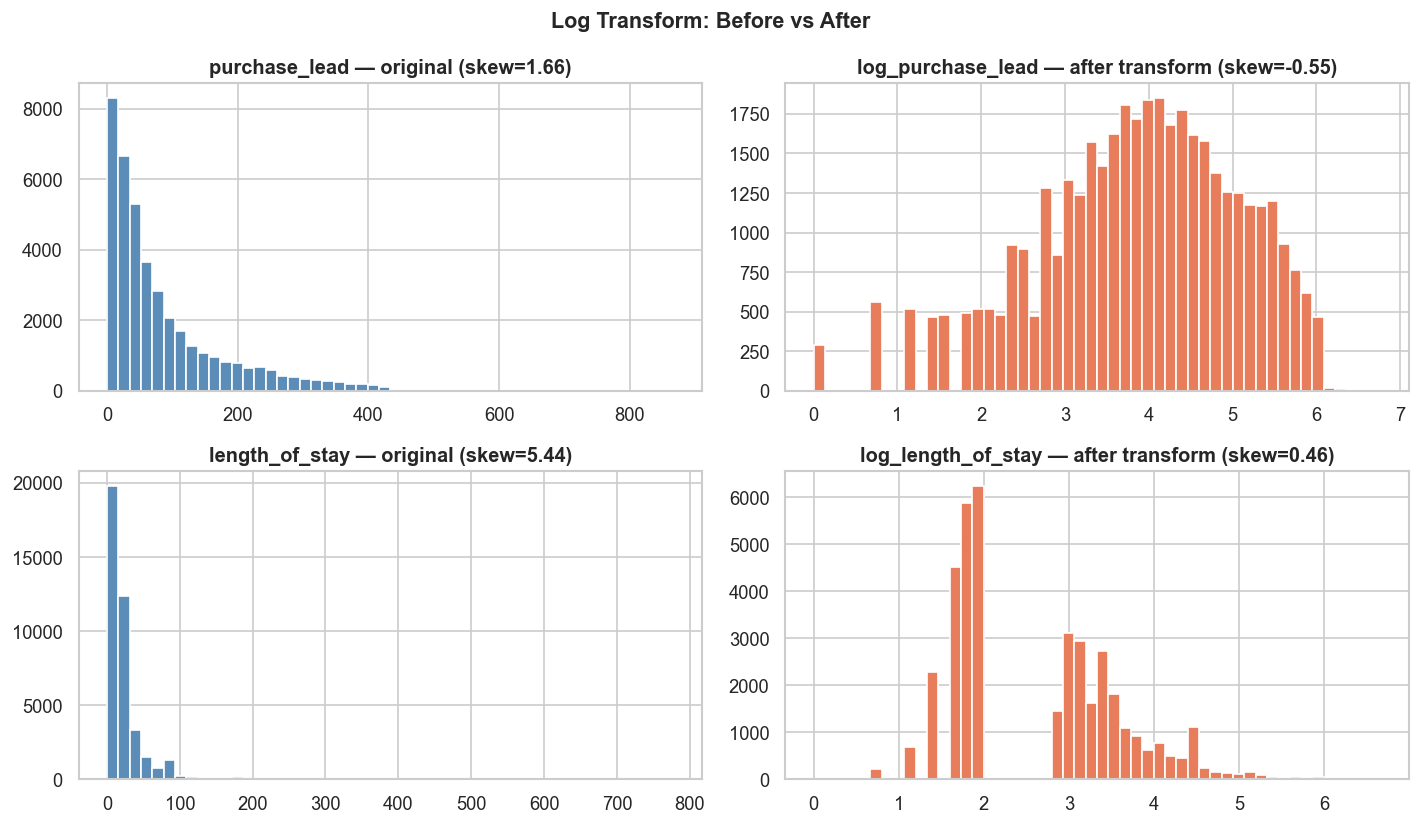

In [ ]:
# --- Log Transforms for Skewed Columns (no leakage — deterministic) ---
for col in ['purchase_lead', 'length_of_stay']:
    X_train[f'log_{col}'] = np.log1p(X_train[col])
    X_test[f'log_{col}']  = np.log1p(X_test[col])

# Visualise before vs after for purchase_lead
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for row, col in enumerate(['purchase_lead', 'length_of_stay']):
    X_train[col].hist(bins=50, ax=axes[row][0], color='#5B8DB8', edgecolor='white')
    axes[row][0].set_title(f'{col} - original (skew={X_train[col].skew():.2f})', fontweight='bold')

    X_train[f'log_{col}'].hist(bins=50, ax=axes[row][1], color='#E87D5B', edgecolor='white')
    axes[row][1].set_title(f'log_{col} - after transform (skew={X_train[f"log_{col}"].skew():.2f})', fontweight='bold')

plt.suptitle('Log Transform: Before vs After', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Drop originals — log versions replace them
X_train = X_train.drop(columns=['purchase_lead', 'length_of_stay'])
X_test  = X_test.drop(columns=['purchase_lead', 'length_of_stay'])

In [15]:
# --- One-Hot Encode: sales_channel, trip_type (nominal, low cardinality) ---
ohe_cols = ['sales_channel', 'trip_type']

X_train = pd.get_dummies(X_train, columns=ohe_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=ohe_cols, drop_first=True)

# Align test to train columns (in case a category only appeared in one split)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print('After OHE:', [c for c in X_train.columns if 'channel' in c or 'trip' in c])

After OHE: ['sales_channel_Mobile', 'trip_type_OneWay', 'trip_type_RoundTrip']


In [16]:
# --- Frequency Encode: route, booking_origin, route_origin, route_dest ---
# Fit on train only — apply same map to test
freq_cols = ['route', 'booking_origin', 'route_origin', 'route_dest']

freq_maps = {}
for col in freq_cols:
    freq_map = X_train[col].value_counts()          # fit on train
    freq_maps[col] = freq_map
    X_train[f'{col}_freq'] = X_train[col].map(freq_map)
    X_test[f'{col}_freq']  = X_test[col].map(freq_map).fillna(1)  # unseen → 1

# Drop original string columns
X_train = X_train.drop(columns=freq_cols)
X_test  = X_test.drop(columns=freq_cols)

print('Frequency-encoded columns added:')
print([c for c in X_train.columns if '_freq' in c])

Frequency-encoded columns added:
['route_freq', 'booking_origin_freq', 'route_origin_freq', 'route_dest_freq']


In [17]:
# --- Final Check ---
print('Final training set shape:', X_train.shape)
print('Final test set shape:    ', X_test.shape)
print()
print('Any nulls in train:', X_train.isnull().sum().sum())
print('Any nulls in test: ', X_test.isnull().sum().sum())
print()
print('Final feature list:')
for c in X_train.columns:
    print(f'  {c}  [{X_train[c].dtype}]')

Final training set shape: (40000, 19)
Final test set shape:     (10000, 19)

Any nulls in train: 0
Any nulls in test:  0

Final feature list:
  num_passengers  [int64]
  flight_hour  [int64]
  flight_day  [int64]
  wants_extra_baggage  [int64]
  wants_preferred_seat  [int64]
  wants_in_flight_meals  [int64]
  flight_duration  [float64]
  total_ancillaries  [int64]
  is_weekend  [int32]
  is_solo  [int32]
  log_purchase_lead  [float64]
  log_length_of_stay  [float64]
  sales_channel_Mobile  [bool]
  trip_type_OneWay  [bool]
  trip_type_RoundTrip  [bool]
  route_freq  [int64]
  booking_origin_freq  [int64]
  route_origin_freq  [int64]
  route_dest_freq  [int64]


In [18]:
# Save processed sets so the modelling notebook can load them directly
X_train.assign(booking_complete=y_train.values).to_csv('processed_train.csv', index=False)
X_test.assign(booking_complete=y_test.values).to_csv('processed_test.csv', index=False)
print('Saved: processed_train.csv and processed_test.csv')

Saved: processed_train.csv and processed_test.csv
